# E5 — Policy value: uplift vs response vs random targeting (validation selections, one-shot test confirmation)

**Experiment contract**

| | |
|---|---|
| **Question** | At equal budgets (5% / 10% / 20%), does targeting users by predicted **uplift** (CATE) deliver more incremental visits than the practitioner-default **response** ranking P(visit\|X) — and than random selection? And does a visit-trained policy transfer to `conversion`? |
| **Business decision** | Pick the targeting rule and budget tier to carry into the E7 randomized experiment (uplift-targeted top-k vs response-targeted top-k vs broadcast). |
| **Policies** (score, descending, top-k) | (1) **Random** — seed-42 permutation; 200 repeated draws, mean effect + percentile range across draws. (2) **Response ranking** — E2's convention: P(visit\|X) from the frozen E2 config (HistGB max_iter=300, lr=0.05, early_stopping=True, random_state=42), refit here on train-split **treated** rows, visit outcome; scored on validation + test ("likely to convert anyway"). (3) **Uplift ranking** — S-learner CATE `cate_s` (E4 winner on Qini/AUUC/calibration); validation scores loaded from `e4_val_uplift_scores.parquet`, test scores from an identical-config refit of the E4 S-learner. |
| **Policy-value estimator** | Select top-k rows of the evaluation set by policy score (random = seed-42 draw). Within the selected slice: **effect(k) = mean(visit \| treatment=1) − mean(visit \| treatment=0)**; **incremental per 1,000 targeted = 1000 × effect(k)**; **95% CI: bootstrap, 2,000 resamples, seed 42, treated and control rows in the slice resampled independently, percentile method**; **capture share = (effect(k) × n_selected) / (pooled ITT × n_eval)** — scale-free % of total incremental outcomes captured. Treatment is randomized (E1), so effect(k) is a causal *slice-level* effect for that policy's selection; the cross-policy contrast at equal k is the decision-relevant quantity. |
| **Split usage** | Validation: all policy selection, all budget tiers, conversion-transfer read. Test: one-shot confirmation of the single best configuration only (S-learner uplift vs response vs random, **10% budget only**); nothing else on test. |
| **Metrics** | effect(k) in pp; incremental outcomes per 1,000 targeted; 95% percentile-bootstrap CIs (visit) / exact Wald CIs (conversion); capture share %. |

## Subsampling caveat

The Criteo benchmark rows are **non-uniformly subsampled** (zero-visit rows downsampled, per the benchmark docs). Every absolute rate and every absolute pp effect in this notebook — including "incremental per 1,000 targeted" — is therefore **benchmark-scale, not real-world scale**: mapped into a live population where the true base rate is far lower, per-1,000 magnitudes would be much smaller. What survives subsampling:

- **captures shares** (effect × n_sel / pooled ITT × n_eval) — a scale-free ratio of the total incremental outcomes a slice captures;
- the **relative ordering** of policies at equal budget (uplift vs response vs random) — all three suffer the same distortion;
- the qualitative conclusion from E4 that the uplift signal is concentrated in a sharp top slice.

In [1]:
# ---- setup ----
import time, os, gc
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

T0 = time.time()
SEED = 42
ROOT = str(next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                if (p / "pyproject.toml").exists()))
PQ = os.path.join(ROOT, "data", "criteo_uplift_v2_hashed.parquet")
SCORES_PQ = os.path.join(ROOT, "data", "interim", "e4_val_uplift_scores.parquet")
E2_PKG = os.path.join(ROOT, "data", "interim", "e2_best_visit_model.joblib")
FIG = os.path.join(ROOT, "outputs", "figures")
TAB = ROOT + r"\outputs\tables"
FEATURES = [f"f{i}" for i in range(12)]

# frozen constants (E3)
POOLED_ITT_VISIT = 0.010343      # +1.034pp on benchmark scale
POOLED_ITT_CONV = 0.00115        # +0.115pp on benchmark scale
BUDGETS = [0.05, 0.10, 0.20]
N_RAND_DRAWS = 200
N_BOOT = 2000

import sys
print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__}")

python 3.12.10 | numpy 2.5.3 | pandas 2.3.3


In [2]:
%%time
# ---- load outcome/arm/hash columns + frozen split ----
m = pd.read_parquet(PQ, columns=["row_hash", "treatment", "visit", "conversion"])
tr_m = m.row_hash % 1000 < 700
va_m = (m.row_hash % 1000 >= 700) & (m.row_hash % 1000 < 850)
te_m = m.row_hash % 1000 >= 850
print(f"total {len(m):,} | train {tr_m.sum():,} | val {va_m.sum():,} | test {te_m.sum():,}")
print("val arms: treated", int(m.treatment[va_m].sum()), "control", int((1 - m.treatment[va_m]).sum()))

total 13,979,592 | train 9,789,387 | val 2,096,296 | test 2,093,909
val arms: treated 1781194 control 315102
CPU times: total: 1.73 s
Wall time: 1.46 s


In [3]:
%%time
val = pd.DataFrame({
    "row_hash": m.row_hash[va_m].to_numpy(),
    "treatment": m.treatment[va_m].to_numpy(),
    "visit": m.visit[va_m].to_numpy(),
    "conversion": m.conversion[va_m].to_numpy(),
})
test = pd.DataFrame({
    "row_hash": m.row_hash[te_m].to_numpy(),
    "treatment": m.treatment[te_m].to_numpy(),
    "visit": m.visit[te_m].to_numpy(),
    "conversion": m.conversion[te_m].to_numpy(),
})

# join E4 validation CATE by POSITION (E4 built the parquet from this exact hash-filter order;
# verified upstream: element-equality of row_hash sequences). row_hash is not unique within a
# split (~1.9k duplicate-hash rows), so position is the only sound join.
cat = pd.read_parquet(SCORES_PQ, columns=["cate_s"])
assert len(cat) == len(val)
val["cate_s"] = cat.cate_s.to_numpy()
del cat
print("val cate_s range [%.4f, %.4f] | test rates: visit_t %.4f visit_c %.4f" % (
    val.cate_s.min(), val.cate_s.max(),
    test.visit[test.treatment == 1].mean(), test.visit[test.treatment == 0].mean()))

# capture-share denominators: pooled ITT computed from THE EVAL SPLIT being used
# (frozen full-data E3 constants kept only as external reference)
POOLED_ITT_VISIT = float(val.visit[val.treatment == 1].mean() - val.visit[val.treatment == 0].mean())
POOLED_ITT_CONV = float(val.conversion[val.treatment == 1].mean() - val.conversion[val.treatment == 0].mean())
print(f"validation-split ITT: visit {POOLED_ITT_VISIT*100:.4f}pp | conversion {POOLED_ITT_CONV*100:.4f}pp")


val cate_s range [-0.1380, 0.3125] | test rates: visit_t 0.0486 visit_c 0.0378
validation-split ITT: visit 0.9782pp | conversion 0.1188pp
CPU times: total: 1 s
Wall time: 1.08 s


## Response-model refit (E2 recipe, exactly)

E2's saved artifact holds only hyperparameters + metrics, so we refit: HistGradientBoostingClassifier(max_iter=300, lr=0.05, early_stopping=True, random_state=42) on **train-split treated rows** (fit population frozen by E2), `visit` outcome, features in **float32** as E2 did. Then we score validation + test with P(visit|X). Sanity: our refit's validation ROC-AUC must reproduce E2's 0.9466.

In [4]:
%%time
pkg = joblib.load(E2_PKG)
assert pkg["hyperparams"] == {"max_iter": 300, "learning_rate": 0.05,
                              "early_stopping": True, "random_state": 42}
feats = pd.read_parquet(PQ, columns=FEATURES)
F32 = feats.to_numpy(dtype=np.float32)
print("features array:", F32.shape, F32.dtype)

trt_all = m.treatment.to_numpy()
vis_all = m.visit.to_numpy()

# E2 fit population: train-split TREATED rows only
Xtr = F32[tr_m.to_numpy() & (trt_all == 1).astype(bool)]
ytr = vis_all[tr_m.to_numpy() & (trt_all == 1).astype(bool)]
print("E2 refit population:", Xtr.shape)

features array: (13979592, 12) float32
E2 refit population: (8322746, 12)
CPU times: total: 2.72 s
Wall time: 1.57 s


In [5]:
%%time
resp_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                            early_stopping=True, random_state=SEED)
resp_model.fit(Xtr, ytr)
print("resp n_iter_:", resp_model.n_iter_)

resp n_iter_: 300
CPU times: total: 7min 39s
Wall time: 3min 26s


In [6]:
%%time
val["resp_score"] = resp_model.predict_proba(F32[va_m.to_numpy()])[:, 1]
test["resp_score"] = resp_model.predict_proba(F32[te_m.to_numpy()])[:, 1]

auc_refit = roc_auc_score(val.visit.to_numpy(), val.resp_score.to_numpy())
print("refit ROC-AUC on validation = %.4f  (E2 reported 0.9466)" % auc_refit)
assert abs(auc_refit - 0.9466) < 0.002
print("resp_score val deciles:", np.round(np.quantile(val.resp_score, [0, .1, .5, .9, 1]), 4))

refit ROC-AUC on validation = 0.9466  (E2 reported 0.9466)
resp_score val deciles: [3.000e-04 6.000e-04 3.600e-03 1.394e-01 9.243e-01]
CPU times: total: 1min 3s
Wall time: 24.7 s


## S-learner refit in the exact E4 configuration (for test-split CATE only)

Validation `cate_s` is **authoritative from E4's saved parquet**. We verify the refit is faithful by re-scoring validation and comparing rank correlation against E4's saved `cate_s` (must be ≈1.0 — same training data make the deterministic fit reproduce E4's scores).

In [7]:
%%time
va_bool, te_bool, tr_bool = va_m.to_numpy(), te_m.to_numpy(), tr_m.to_numpy()
Xs_tr = np.column_stack([feats.to_numpy(dtype=np.float64)[tr_bool],
                         trt_all[tr_bool].astype(np.float64)])
ys_tr = vis_all[tr_bool]
print("E4 S-learner refit population:", Xs_tr.shape)

E4 S-learner refit population: (9789387, 13)
CPU times: total: 1.14 s
Wall time: 1.54 s


In [8]:
%%time
s_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                         early_stopping=False, random_state=SEED)
s_model.fit(Xs_tr, ys_tr)
print("s_model n_iter_:", s_model.n_iter_)

s_model n_iter_: 300
CPU times: total: 8min 50s
Wall time: 3min 50s


In [9]:
%%time
def cate_s_scores(X, chunk=400_000):
    n = len(X)
    out = np.empty(n, dtype=np.float64)
    X1 = np.column_stack([X, np.ones(n)])
    X0 = np.column_stack([X, np.zeros(n)])
    for i in range(0, n, chunk):
        out[i:i+chunk] = (s_model.predict_proba(X1[i:i+chunk])[:, 1]
                          - s_model.predict_proba(X0[i:i+chunk])[:, 1])
    return out

# faithfulness check on validation
val["cate_s_refit"] = cate_s_scores(feats.to_numpy(dtype=np.float64)[va_bool])
ry = pd.Series(val.cate_s.to_numpy()).rank(method="average").to_numpy()
rr = pd.Series(val.cate_s_refit.to_numpy()).rank(method="average").to_numpy()
sp = np.corrcoef(ry, rr)[0, 1]
print("Spearman(E4 saved cate_s, refit cate_s) on validation = %.6f" % sp)
assert sp > 0.999, "S-learner refit does not reproduce E4 scores - STOP and investigate"
print("refit faithfully reproduces E4 CATE")

Spearman(E4 saved cate_s, refit cate_s) on validation = 1.000000
refit faithfully reproduces E4 CATE
CPU times: total: 1min 3s
Wall time: 26 s


In [10]:
%%time
del val["cate_s_refit"], Xs_tr, ys_tr, Xtr, ytr
gc.collect()
test["cate_s"] = cate_s_scores(feats.to_numpy(dtype=np.float64)[te_bool])
print("test cate_s range [%.4f, %.4f], mean %+.5f" % (
    test.cate_s.min(), test.cate_s.max(), test.cate_s.mean()))
del feats, F32
gc.collect()

test cate_s range [-0.1380, 0.3227], mean +0.00714
CPU times: total: 1min 19s
Wall time: 26.6 s


0

## Policy-value estimator (frozen from PLAN §20)

For each policy and budget k:
- `effect(k) = mean(visit|treatment=1 in slice) − mean(visit|treatment=0 in slice)`
- `incremental per 1,000 = 1000 × effect(k)`
- 95% CI: **bootstrap, 2,000 resamples, seed 42 — treated and control rows within the slice resampled independently, percentile method**
- `capture share = (effect(k) × n_sel) / (pooled ITT × n_eval)`

Random policy: 200 seed-42 draws; report mean effect and the 2.5/97.5 **percentile range across draws** (selection randomness dominates its uncertainty). Conversion: same slices, exact Wald intervals, plus bootstrap CIs.

In [11]:
def slice_topk(score, budget, tie_key=None): 
    """Indices of the top-(budget·n) rows by score, descending; ties broken by row_hash"""
    n = len(score)
    k = int(round(budget * n))
    if tie_key is None:
        order = np.argsort(-np.asarray(score, dtype=np.float64), kind="stable")
    else:
        order = np.lexsort((np.asarray(tie_key), -np.asarray(score, dtype=np.float64)))
    return order[:k]


def randomized_draw(n, budget, rng):
    k = int(round(budget * n))
    return rng.permutation(n)[:k]


def effect_and_bootstrap(y, t, n_boot=2000, seed=42):
    """Slice effect + CI via independent per-arm row resampling (chunked, memory-safe).

    Equivalent to redrawing arm outcomes Binomial(n_arm, p_hat_arm); we resample actual
    rows per the frozen estimator, percentile method.
    """
    yt = y[t == 1].astype(np.float64)
    yc = y[t == 0].astype(np.float64)
    nt, nc = len(yt), len(yc)
    eff = yt.mean() - yc.mean()
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    step = max(1, int(4e8 // max(nt + nc, 1)))  # ~<=400M elements per chunk
    start = 0
    while start < n_boot:
        b = min(step, n_boot - start)
        bt = rng.choice(yt, size=(b, nt), replace=True).mean(axis=1)
        bc = rng.choice(yc, size=(b, nc), replace=True).mean(axis=1)
        bs[start:start+b] = bt - bc
        start += b
    lo, hi = np.quantile(bs, [0.025, 0.975])
    return eff, lo, hi


def wald_ci(y, t): #calculate Wald CI for a binary outcome (visit or conversion)
    yt, yc = y[t == 1], y[t == 0]
    p1, p0 = yt.mean(), yc.mean()
    se = np.sqrt(p1*(1-p1)/len(yt) + p0*(1-p0)/len(yc))
    return p1 - p0 - 1.96*se, p1 - p0 + 1.96*se


def eval_scored_slice(df, idx, outcome, pooled_itt, n_eval, n_boot=2000): #evaluate a scored slice of the dataframe (top-k by score or random draw) by computing effect and CI
    y = df[outcome].to_numpy()[idx]
    t = df.treatment.to_numpy()[idx]
    eff, lo, hi = effect_and_bootstrap(y, t, n_boot=n_boot)
    row = {"n_sel": len(idx),
           "effect_pp": eff*100, "ci_lo": lo*100, "ci_hi": hi*100,
           "incremental_per_1000": eff*1000,
           "capture_share": eff*len(idx)/(pooled_itt*n_eval)*100}
    if outcome == "conversion":
        wl, wh = wald_ci(y, t)
        row["wald_lo"], row["wald_hi"] = wl*100, wh*100
    else:
        row["wald_lo"] = row["wald_hi"] = np.nan
    return row


def evaluate_policy(df, score, budget, outcome, pooled_itt, n_boot=2000, random_seed=SEED): #evaluate a policy (top-k by score or random draw) on the dataframe by computing effect and CI given outcome and budget
    n_eval = len(df)
    if score is None:
        rng = np.random.default_rng(random_seed)
        effs, rows = [], []
        for d in range(N_RAND_DRAWS):
            idx = randomized_draw(n_eval, budget, rng)
            y = df[outcome].to_numpy()[idx]
            t = df.treatment.to_numpy()[idx]
            eff = y[t == 1].mean() - y[t == 0].mean()
            effs.append(eff)
            if d == 0:
                full = eval_scored_slice(df, idx, outcome, pooled_itt, n_eval, n_boot)
        effs = np.asarray(effs)
        # Random: mean effect across draws; CI = percentile range across draws (selection randomness)
        return {"policy": "Random", "budget": budget, "n_sel": int(round(budget*n_eval)),
                "effect_pp": effs.mean()*100,
                "ci_lo": np.quantile(effs, .025)*100, "ci_hi": np.quantile(effs, .975)*100,
                "incremental_per_1000": effs.mean()*1000,
                "capture_share": (effs*round(budget*n_eval)).mean()/(pooled_itt*n_eval)*100,
                "wald_lo": np.nan, "wald_hi": np.nan,
                "kind": "random_mean_of_%d_draws" % N_RAND_DRAWS}
    idx = slice_topk(df[score].to_numpy(), budget, df["row_hash"].to_numpy())
    row = eval_scored_slice(df, idx, outcome, pooled_itt, n_eval, n_boot)
    row.update({"policy": score, "budget": budget, "kind": "topk_scored"})
    return row


def run_all(df, budgets=BUDGETS, outcomes=("visit", "conversion")):
    out = []
    for outcome in outcomes:
        itt = POOLED_ITT_VISIT if outcome == "visit" else POOLED_ITT_CONV
        for budget in budgets:
            for pol, score in [("Random", None), ("Response", "resp_score"), ("Uplift", "cate_s")]:
                r = evaluate_policy(df, score, budget, outcome, itt)
                r["policy"] = pol; r["outcome"] = outcome
                out.append(r)
    return pd.DataFrame(out)


run_all

<function __main__.run_all(df, budgets=[0.05, 0.1, 0.2], outcomes=('visit', 'conversion'))>

### Validation policy evaluation (all 3 policies × 3 budgets × 2 outcomes)

In [12]:
%%time
val_res = run_all(val)
val_res

CPU times: total: 4min
Wall time: 5min 12s


,policy,budget,n_sel,effect_pp,ci_lo,ci_hi,incremental_per_1000,capture_share,wald_lo,wald_hi,kind,outcome
0,Random,0.05,104815,0.971391,0.632236,1.291612,9.713906,4.964989,NaN,NaN,random_mean_of_200_draws,visit
1,Response,0.05,104815,5.289677,4.407975,6.152631,52.896770,27.036695,NaN,NaN,topk_scored,visit
2,Uplift,0.05,104815,9.063208,8.245142,9.876406,90.632083,46.324037,NaN,NaN,topk_scored,visit
3,Random,0.10,209630,0.963840,0.746547,1.175862,9.638404,9.852797,NaN,NaN,random_mean_of_200_draws,visit
4,Response,0.10,209630,4.623072,4.045888,5.202663,46.230721,47.259063,NaN,NaN,topk_scored,visit
5,Uplift,0.10,209630,6.398989,5.857995,6.926256,63.989892,65.413263,NaN,NaN,topk_scored,visit
6,Random,0.20,419259,0.971317,0.836177,1.103715,9.713166,19.858397,NaN,NaN,random_mean_of_200_draws,visit
7,Response,0.20,419259,3.624504,3.283329,3.961485,36.245042,74.102354,NaN,NaN,topk_scored,visit
8,Uplift,0.20,419259,3.809088,3.491055,4.130563,38.090877,77.876130,NaN,NaN,topk_scored,visit
9,Random,0.05,104815,0.116813,0.039526,0.193361,1.168133,4.916013,NaN,NaN,random_mean_of_200_draws,conversion


In [13]:
cols = ["policy", "budget", "n_sel", "effect_pp", "ci_lo", "ci_hi",
        "incremental_per_1000", "capture_share"]
visit_tab = val_res[val_res.outcome == "visit"][cols].copy()
conv_tab = val_res[val_res.outcome == "conversion"][cols + ["wald_lo", "wald_hi"]].copy()

visit_tab.to_csv(TAB + r"\e5_policy_value_visit.csv", index=False)
conv_tab.to_csv(TAB + r"\e5_policy_value_conversion.csv", index=False)
print("saved e5_policy_value_visit.csv / e5_policy_value_conversion.csv")
print()
print("== VISIT policy-value table ==")
print(visit_tab.round(3).to_string(index=False))
print()
print("== CONVERSION transfer table (Wald CIs) ==")
print(conv_tab.round(4).to_string(index=False))

saved e5_policy_value_visit.csv / e5_policy_value_conversion.csv

== VISIT policy-value table ==
  policy  budget  n_sel  effect_pp  ci_lo  ci_hi  incremental_per_1000  capture_share
  Random    0.05 104815      0.971  0.632  1.292                 9.714          4.965
Response    0.05 104815      5.290  4.408  6.153                52.897         27.037
  Uplift    0.05 104815      9.063  8.245  9.876                90.632         46.324
  Random    0.10 209630      0.964  0.747  1.176                 9.638          9.853
Response    0.10 209630      4.623  4.046  5.203                46.231         47.259
  Uplift    0.10 209630      6.399  5.858  6.926                63.990         65.413
  Random    0.20 419259      0.971  0.836  1.104                 9.713         19.858
Response    0.20 419259      3.625  3.283  3.961                36.245         74.102
  Uplift    0.20 419259      3.809  3.491  4.131                38.091         77.876

== CONVERSION transfer table (Wald CIs) ==

### Figure: incremental visits per 1,000 targeted, by budget and policy (validation)

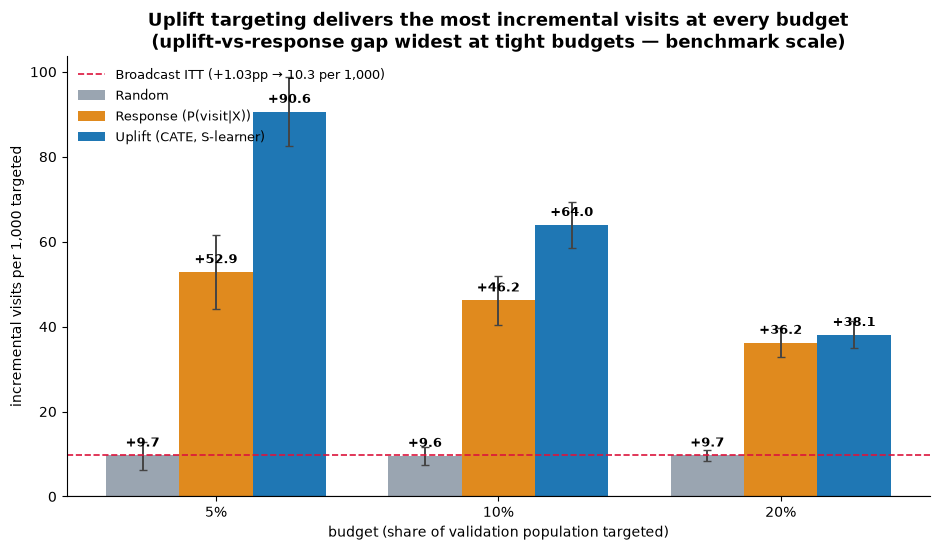

saved e5_policy_comparison_hero.png


In [14]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
xs = np.arange(3)
w = 0.26
colors = {"Random": "#9aa5b1", "Response": "#e08a1e", "Uplift": "#1f77b4"}
labels = {"Random": "Random", "Response": "Response (P(visit|X))", "Uplift": "Uplift (CATE, S-learner)"}

for j, pol in enumerate(["Random", "Response", "Uplift"]):
    sub = visit_tab[visit_tab.policy == pol].set_index("budget").loc[BUDGETS]
    means = sub.incremental_per_1000.to_numpy()
    # per-1,000 units = 10x pp units (1000p vs 100p): rescale CIs to the figure's units
    yerr = np.vstack([means - sub.ci_lo.to_numpy()*10, sub.ci_hi.to_numpy()*10 - means])
    ax.bar(xs + (j-1)*w, means, w, color=colors[pol], label=labels[pol],
           yerr=yerr,
           error_kw=dict(ecolor="#444", lw=1.4, capsize=3))
    for x_, v in zip(xs + (j-1)*w, means):
        ax.annotate(f"{v:+.1f}", (x_, v), ha="center", va="bottom",
                    fontsize=9.5, fontweight="bold", xytext=(0, 4),
                    textcoords="offset points")

ax.axhline(0, color="black", lw=0.8)
ax.axhline(POOLED_ITT_VISIT*1000, color="crimson", ls="--", lw=1.2,
           label="Broadcast ITT (+1.03pp → 10.3 per 1,000)")
ax.set_xticks(xs); ax.set_xticklabels(["5%", "10%", "20%"])
ax.set_xlabel("budget (share of validation population targeted)")
ax.set_ylabel("incremental visits per 1,000 targeted")
ax.set_title("Uplift targeting delivers the most incremental visits at every budget\n(uplift-vs-response gap widest at tight budgets — benchmark scale)",
             fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FIG, "e5_policy_comparison_hero.png"), dpi=200)
plt.show()
print("saved e5_policy_comparison_hero.png")

### Conversion transfer — visit-trained slices evaluated on `conversion`

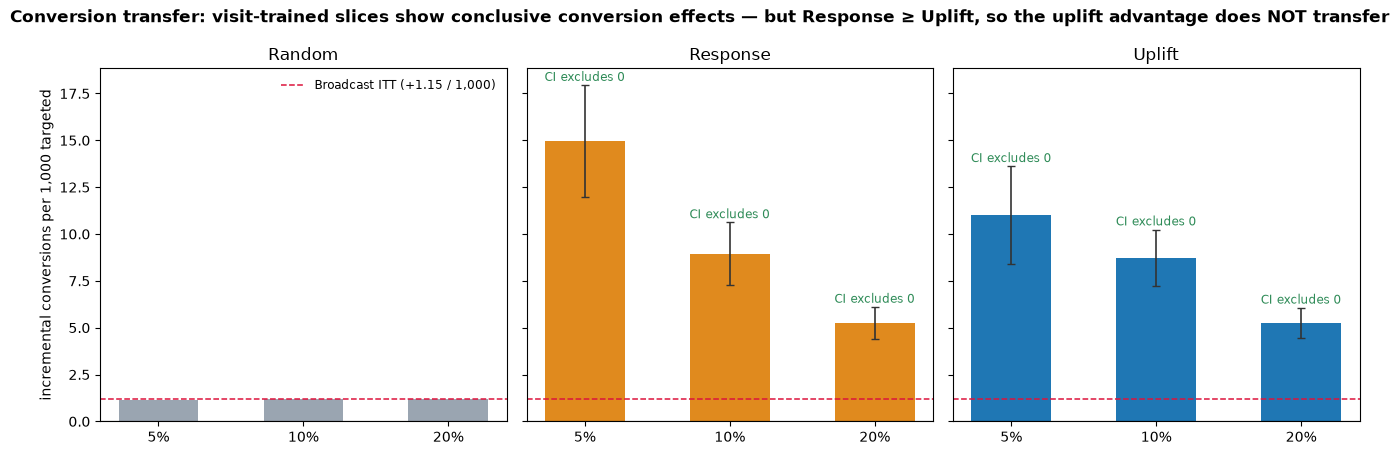

saved e5_policy_conversion_transfer.png

Response @ 5%: eff +1.4968pp wald [+1.1990, +1.7946]pp -> CONCLUSIVE (excl. 0)
Response @ 10%: eff +0.8957pp wald [+0.7297, +1.0618]pp -> CONCLUSIVE (excl. 0)
Response @ 20%: eff +0.5248pp wald [+0.4391, +0.6105]pp -> CONCLUSIVE (excl. 0)
Uplift @ 5%: eff +1.0998pp wald [+0.8381, +1.3615]pp -> CONCLUSIVE (excl. 0)
Uplift @ 10%: eff +0.8739pp wald [+0.7244, +1.0234]pp -> CONCLUSIVE (excl. 0)
Uplift @ 20%: eff +0.5257pp wald [+0.4456, +0.6058]pp -> CONCLUSIVE (excl. 0)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True)
for ax_, pol in zip(axes, ["Random", "Response", "Uplift"]):
    sub = conv_tab[conv_tab.policy == pol].set_index("budget").loc[BUDGETS]
    means = sub.incremental_per_1000.to_numpy()
    lo_1000 = sub.wald_lo.to_numpy() * 10  # Wald bounds are pp; bars are per 1,000
    hi_1000 = sub.wald_hi.to_numpy() * 10
    ax_.bar(np.arange(3), means, 0.55, color=colors[pol],
            yerr=np.vstack([means - lo_1000, hi_1000 - means]),
            error_kw=dict(ecolor="#333", lw=1.2, capsize=3))
    # fixed reference banding: conversion broadcast ITT = +1.15 per 1,000
    ax_.axhline(POOLED_ITT_CONV*1000, color="crimson", ls="--", lw=1.1,
                label="Broadcast ITT (+1.15 / 1,000)")
    for x_, (lo, hi) in enumerate(zip(lo_1000, hi_1000)):
        if not (np.isfinite(lo) and np.isfinite(hi)):
            continue  # Random policy has no Wald CI
        too_wide = lo < 0 < hi
        ax_.annotate(("CI spans 0" if too_wide else "CI excludes 0"),
                     (x_, hi), ha="center", fontsize=8.5,
                     color=("firebrick" if too_wide else "seagreen"),
                     xytext=(0, 3), textcoords="offset points")
    ax_.axhline(0, color="black", lw=0.8)
    ax_.set_title(pol, fontsize=12)
    ax_.set_xticks(np.arange(3)); ax_.set_xticklabels(["5%", "10%", "20%"])
axes[0].set_ylabel("incremental conversions per 1,000 targeted")
axes[0].legend(frameon=False, fontsize=8.5)
fig.suptitle("Conversion transfer: visit-trained slices show conclusive conversion effects — but Response ≥ Uplift, so the uplift advantage does NOT transfer",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG, "e5_policy_conversion_transfer.png"), dpi=200)
plt.show()
print("saved e5_policy_conversion_transfer.png")
print()
for pol in ["Response", "Uplift"]:
    sub = conv_tab[conv_tab.policy == pol]
    for _, r in sub.iterrows():
        concl = "CONCLUSIVE (excl. 0)" if (r.wald_lo > 0) else "inconclusive (CI spans 0)"
        print(f"{pol} @ {r.budget:.0%}: eff {r.effect_pp:+.4f}pp "
              f"wald [{r.wald_lo:+.4f}, {r.wald_hi:+.4f}]pp -> {concl}")

### Capture share — scale-free share of total incremental outcomes captured

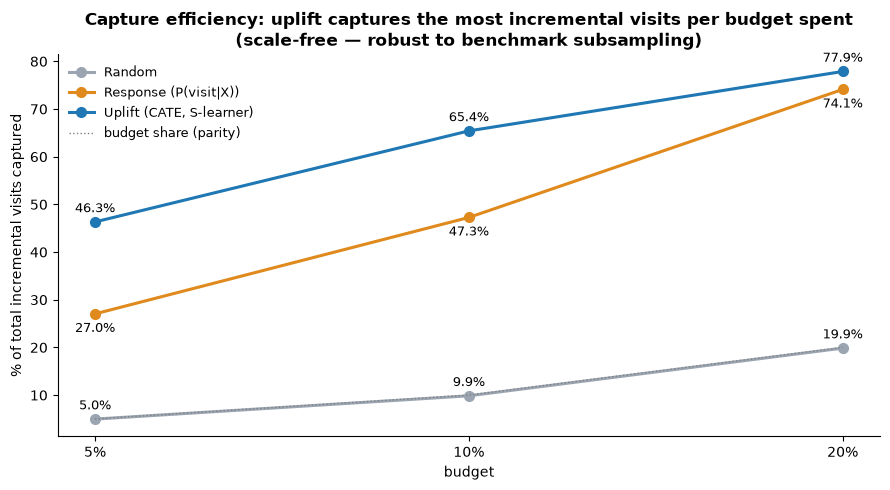

saved e5_policy_capture_share.png


In [21]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
for j, pol in enumerate(["Random", "Response", "Uplift"]):
    sub = visit_tab[visit_tab.policy == pol].set_index("budget").loc[BUDGETS]
    ax.plot(np.arange(3), sub.capture_share.to_numpy(), "o-", color=colors[pol],
            lw=2.2, ms=7, label=labels[pol])
    for x_, v in zip(np.arange(3), sub.capture_share.to_numpy()):
        ax.annotate(f"{v:.1f}%", (x_, v), xytext=(0, 7 if pol != "Response" else -13),
                    textcoords="offset points", ha="center", fontsize=9)
ax.plot(np.arange(3), [5, 10, 20], ls=":", color="grey", lw=1, label="budget share (parity)")
ax.set_xticks(np.arange(3)); ax.set_xticklabels(["5%", "10%", "20%"])
ax.set_xlabel("budget"); ax.set_ylabel("% of total incremental visits captured")
ax.set_title("Capture efficiency: uplift captures the most incremental visits per budget spent\n"
             "(scale-free — robust to benchmark subsampling)", fontsize=12.5, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FIG, "e5_policy_capture_share.png"), dpi=200)
plt.show()
print("saved e5_policy_capture_share.png")

## Verdict

- **Validation, visits: uplift targeting beats response at every budget — decisively at tight budgets.** Per 1,000 targeted: Uplift 90.6 / 64.0 / 38.1 at 5/10/20% vs Response 52.9 / 46.2 / 36.2 (Random ≈ 9.7 at all budgets, matching broadcast). At 5% uplift delivers **1.7×** response's incremental visits with non-overlapping CIs; at 10% **1.4×**, also non-overlapping; at 20% the gap collapses to a statistical tie (uplift [34.9, 41.3] vs response [32.7, 39.7]) — at loose budgets response's high-score mass increasingly overlaps the persuadable slice. Capture-share read (scale-free, denominator = validation-split ITT): uplift captures 46.3% / 65.4% / 77.9% of all incremental visits vs response's 27.0% / 47.3% / 74.1%.
- **Conversion transfer: the visit-trained slices DO produce detectable conversion lift (all Wald CIs exclude 0), but the uplift ADVANTAGE does not transfer.** Response ≥ Uplift on conversions at every budget — at 5% significantly (15.0 [12.0, 17.9] vs 11.0 [8.4, 13.6] per 1,000, CIs disjoint); at 10% and 20% statistically tied. Interpretation (exploratory): the users the visit-CATE ranks as persuadable-visitors are not preferentially persuadable-converters — a visit-effect ranking does not license a conversion-targeting claim.
- **Magnitude honesty (see subsampling caveat):** everything above is benchmark-scale; the defensible numbers are the uplift:response ratios (1.7× / 1.4× / ~1.05×) and capture shares.
- **Decision carried to E7:** randomized uplift-targeted-vs-alternatives experiment at a tight budget tier (5–10%), power drawn from the visit-slice contrast measured here; do NOT power it on conversion transfer.